### Tugas Praktikum 1: Scraping & Eksplorasi Data (EDA)

|     NRP      |     Nama       |
|-----------   |-------------   |
| 5054251013   | Evina Fitriyani| 

### 1. Scraping Dataset

1.1 Sumber Data

Dataset pada praktikum ini diperoleh melalui proses web scraping dari Florida Plant Atlas.

Website: https://florida.plantatlas.usf.edu/

Data diambil menggunakan library Requests dan BeautifulSoup. Data hasil scraping disimpan terlebih dahulu dalam format .csv sebagai data mentah sebelum dilakukan proses pembersihan dan analisis lebih lanjut.

1.2 Import Library

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor

1.3 Mengakses Halaman Website

In [4]:
# Mengakses halaman utama (daftar semua spesies)
url = "https://florida.plantatlas.usf.edu/browse/scientific"
res = requests.get(url)
soup = BeautifulSoup(res.text, "html.parser")

# untuk mengambil semua link menuju halaman detail tiap spesies
links = soup.select("a[href*='/plant/species/']")
print("Jumlah link spesies ditemukan:", len(links))

Jumlah link spesies ditemukan: 4920


In [5]:
# gabungin link relatif jadi link lengkap (https://florida.plantatlas.usf.edu/...)
base_url = "https://florida.plantatlas.usf.edu"

species_list = []
for a in links:
    nama = a.text.strip()
    link = a['href']
    if link.startswith("/"):
        link = base_url + link
    species_list.append([nama, link])

print(species_list[0])

['Abdra brachycarpa', 'https://florida.plantatlas.usf.edu/plant/species/3936']


1.4 Ekstraksi Data

In [6]:
 # fungsi buat ambil detail dari 1 halaman spesies
def ambil_detail(url):
    r = requests.get(url, timeout=10)
    s = BeautifulSoup(r.text, "html.parser")
    teks = s.get_text("\n")
    baris = [b.strip() for b in teks.split("\n") if b.strip() != ""]

    # cari posisi kata "Characteristics" sebagai patokan awal info yang mau diambil
    try:
        start = baris.index("Characteristics")
    except ValueError:
        start = 0
    bagian = baris[start:start+40]

    label_target = ["Family", "Genus", "Common Name", "Growth Habit", "Status"]
    hasil = {}
    for label in label_target:
        hasil[label] = None
        for i in range(len(bagian) - 1):
            if bagian[i] == label:
                hasil[label] = bagian[i+1]
                break
    return hasil

In [7]:
# mengambil lebih dari 1500 karena beberapa halaman takut gagal diakses
# jadi dilebihin ke 1650 biar tetep aman di atas 1500 baris setelah ada yang gagal
jumlah = 1650
target = species_list[:jumlah]

def proses(item):
    nama, link = item
    try:
        detail = ambil_detail(link)
        return [nama, detail["Family"], detail["Genus"], detail["Common Name"],
                 detail["Growth Habit"], detail["Status"], link]
    except:
        return None  
data = []
with ThreadPoolExecutor(max_workers=15) as executor:
    hasil_semua = executor.map(proses, target)
    for i, hasil in enumerate(hasil_semua):
        if hasil is not None:
            data.append(hasil)
        if i % 100 == 0:
            print(i, "sudah diproses")

print("Total data berhasil diambil:", len(data))

0 sudah diproses
100 sudah diproses
200 sudah diproses
300 sudah diproses
400 sudah diproses
500 sudah diproses
600 sudah diproses
700 sudah diproses
800 sudah diproses
900 sudah diproses
1000 sudah diproses
1100 sudah diproses
1200 sudah diproses
1300 sudah diproses
1400 sudah diproses
1500 sudah diproses
1600 sudah diproses
Total data berhasil diambil: 1643


1.5 Menyimpan Data Mentah

In [8]:
# 1.5 Menyimpan data mentah ke csv sebelum diproses lebih lanjut
df_mentah = pd.DataFrame(data, columns=["scientific_name", "family", "genus",
                                          "common_name", "growth_habit", "status", "url"])
df_mentah.to_csv("plant_atlas_raw.csv", index=False)
print(df_mentah.shape)
df_mentah.head()

(1643, 7)


,scientific_name,family,genus,common_name,growth_habit,status,url
0,Abdra brachycarpa,BRASSICACEAE,Abdra,SHORTPOD WHITLOWGRASS,**,Native,https://florida.plantatlas.usf.edu/plant/speci...
1,Abelia x grandiflora,CAPRIFOLIACEAE,Abelia,LARGEFLOWER ABELIA,**,Not Native,https://florida.plantatlas.usf.edu/plant/speci...
2,Abelmoschus esculentus,MALVACEAE,Abelmoschus,OKRA,**,Not Native,https://florida.plantatlas.usf.edu/plant/speci...
3,Abildgaardia ovata,CYPERACEAE,Abildgaardia,FLATSPIKE SEDGE,**,Native,https://florida.plantatlas.usf.edu/plant/speci...
4,Abrus precatorius,FABACEAE,Abrus,ROSARY PEA; BLACKEYED SUSAN,**,Not Native,https://florida.plantatlas.usf.edu/plant/speci...


### 2. Import dan Pemahaman Dataset

2.1 Import Dataset

In [9]:
df = pd.read_csv("plant_atlas_raw.csv")

# tambah 2 fitur turunan numerik, karena data mentah dari situs ini
# semua kolomnya berupa teks/kategorikal jadi butuh fitur numerik
df["panjang_nama_ilmiah"] = df["scientific_name"].astype(str).apply(len)
df["jumlah_kata_common_name"] = df["common_name"].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)

# 2.2 Lihat 5 data pertama
df.head()

,scientific_name,family,genus,common_name,growth_habit,status,url,panjang_nama_ilmiah,jumlah_kata_common_name
0,Abdra brachycarpa,BRASSICACEAE,Abdra,SHORTPOD WHITLOWGRASS,**,Native,https://florida.plantatlas.usf.edu/plant/speci...,17,2
1,Abelia x grandiflora,CAPRIFOLIACEAE,Abelia,LARGEFLOWER ABELIA,**,Not Native,https://florida.plantatlas.usf.edu/plant/speci...,20,2
2,Abelmoschus esculentus,MALVACEAE,Abelmoschus,OKRA,**,Not Native,https://florida.plantatlas.usf.edu/plant/speci...,22,1
3,Abildgaardia ovata,CYPERACEAE,Abildgaardia,FLATSPIKE SEDGE,**,Native,https://florida.plantatlas.usf.edu/plant/speci...,18,2
4,Abrus precatorius,FABACEAE,Abrus,ROSARY PEA; BLACKEYED SUSAN,**,Not Native,https://florida.plantatlas.usf.edu/plant/speci...,17,4


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1643 entries, 0 to 1642
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   scientific_name          1643 non-null   str  
 1   family                   888 non-null    str  
 2   genus                    888 non-null    str  
 3   common_name              888 non-null    str  
 4   growth_habit             888 non-null    str  
 5   status                   888 non-null    str  
 6   url                      1643 non-null   str  
 7   panjang_nama_ilmiah      1643 non-null   int64
 8   jumlah_kata_common_name  1643 non-null   int64
dtypes: int64(2), str(7)
memory usage: 115.7 KB


In [11]:
df.shape

(1643, 9)

In [12]:
df.dtypes

scientific_name              str
family                       str
genus                        str
common_name                  str
growth_habit                 str
status                       str
url                          str
panjang_nama_ilmiah        int64
jumlah_kata_common_name    int64
dtype: object

In [13]:
# Identifikasi Tipe Atribut
print("""
scientific_name         : Nominal
family                  : Nominal
genus                   : Nominal
common_name             : Nominal
status                  : Ordinal
url                     : Nominal
panjang_nama_ilmiah     : Numerik diskrit
jumlah_kata_common_name : Numerik diskrit
""")


scientific_name         : Nominal
family                  : Nominal
genus                   : Nominal
common_name             : Nominal
status                  : Ordinal
url                     : Nominal
panjang_nama_ilmiah     : Numerik diskrit
jumlah_kata_common_name : Numerik diskrit



### 3. Analisis Statistik dan Kualitas Data

3.1 Statistik Deskriptif Atribut Numerik

Analisis statistik deskriptif dilakukan untuk mengetahui karakteristik atribut numerik pada dataset.

Statistik yang dihitung meliputi:

- Mean
- Median
- Modus
- Standar deviasi
- Nilai minimum
- Nilai maksimum

In [14]:
 # Statistik deskriptif atribut numerik
df[["panjang_nama_ilmiah", "jumlah_kata_common_name"]].describe()

,panjang_nama_ilmiah,jumlah_kata_common_name
count,1643.000000,1643.000000
mean,19.973220,1.219111
std,5.291665,1.349679
min,9.000000,0.000000
25%,17.000000,0.000000
50%,19.000000,1.000000
75%,22.000000,2.000000
max,45.000000,8.000000


In [15]:
# modus masing-masing atribut numerik
print("Modus panjang_nama_ilmiah:", df["panjang_nama_ilmiah"].mode()[0])
print("Modus jumlah_kata_common_name:", df["jumlah_kata_common_name"].mode()[0])

Modus panjang_nama_ilmiah: 19
Modus jumlah_kata_common_name: 0


3.2 Frekuensi Atribut Kategorikal

Analisis frekuensi dilakukan untuk mengetahui distribusi data pada atribut kategorikal.

In [16]:
# Frekuensi atribut kategorikal
print(df["family"].value_counts())
print(df["genus"].value_counts())
print(df["growth_habit"].value_counts())
print(df["status"].value_counts())

family
POACEAE              98
FABACEAE             86
CYPERACEAE           79
ASTERACEAE           78
AMARANTHACEAE        33
                     ..
HYDRANGEACEAE         1
HEMEROCALLIDACEAE     1
POLYPODIACEAE         1
DUMORTIERACEAE        1
HYDROCHARITACEAE      1
Name: count, Length: 124, dtype: int64
genus
Carex         32
Eleocharis    31
Aristida      22
Asclepias     22
Desmodium     22
              ..
Echites        1
Eclipta        1
Edrastima      1
**             1
Elaeis         1
Name: count, Length: 328, dtype: int64
growth_habit
**    888
Name: count, dtype: int64
status
Native        557
Not Native    331
Name: count, dtype: int64


 3.3 Missing Values

Pengecekan missing values dilakukan untuk mengetahui apakah terdapat data yang kosong atau tidak tersedia pada setiap atribut.

In [17]:
# bersihin nilai placeholder "**" jadi missing value beneran
df = df.replace("**", pd.NA)

# growth_habit banyak kosong/tidak konsisten di situs sumbernya, jadi didrop
df = df.drop(columns=["growth_habit"])

# 3.3 Cek missing values di tiap kolom
df.isnull().sum()

scientific_name              0
family                     755
genus                      756
common_name                808
status                     755
url                          0
panjang_nama_ilmiah          0
jumlah_kata_common_name      0
dtype: int64

In [18]:
# 3.4 Deteksi outlier pakai metode IQR
def cek_outlier(kolom):
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    return df[(df[kolom] < batas_bawah) | (df[kolom] > batas_atas)]

outlier_panjang = cek_outlier("panjang_nama_ilmiah")
outlier_kata = cek_outlier("jumlah_kata_common_name")
print("Jumlah outlier panjang_nama_ilmiah:", len(outlier_panjang))
print("Jumlah outlier jumlah_kata_common_name:", len(outlier_kata))

Jumlah outlier panjang_nama_ilmiah: 104
Jumlah outlier jumlah_kata_common_name: 12


#### 4. Visualisasi Data


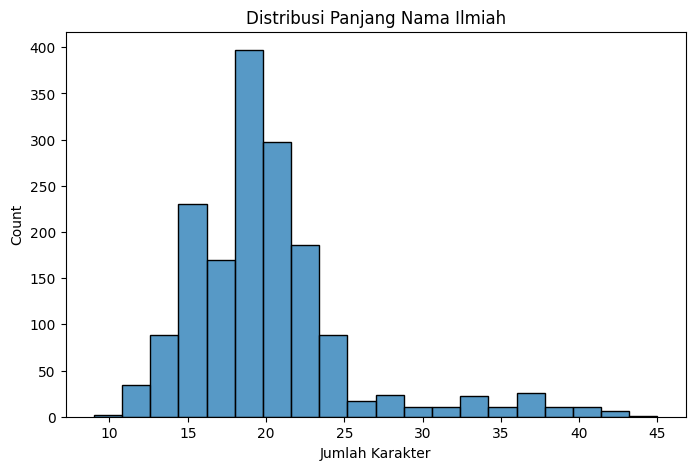

In [19]:

# 4.1 Univariat - distribusi panjang nama ilmiah
plt.figure(figsize=(8,5))
sns.histplot(df["panjang_nama_ilmiah"], bins=20)
plt.title("Distribusi Panjang Nama Ilmiah")
plt.xlabel("Jumlah Karakter")
plt.show()

Sebagian besar nama ilmiah punya panjang karakter di kisaran
tertentu (lihat puncak histogram), dengan sedikit spesies yang nama
ilmiahnya jauh lebih panjang/pendek dari rata-rata ini yang
kedeteksi sebagai outlier

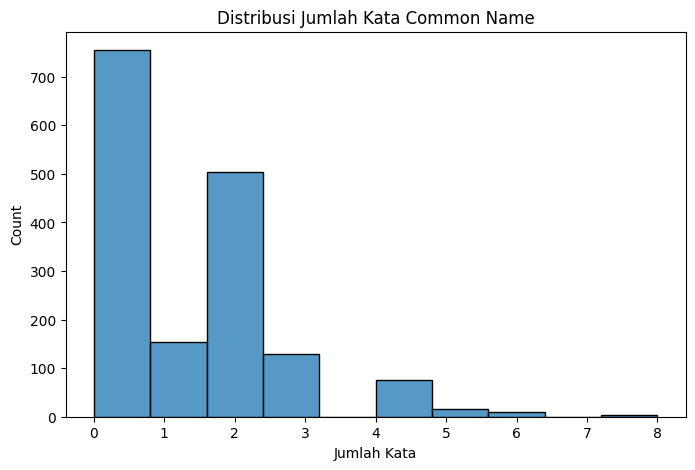

In [20]:
# 4.2 Univariat - distribusi jumlah kata common name
plt.figure(figsize=(8,5))
sns.histplot(df["jumlah_kata_common_name"], bins=10)
plt.title("Distribusi Jumlah Kata Common Name")
plt.xlabel("Jumlah Kata")
plt.show()

Kebanyakan common name terdiri dari 0-2 kata (bahkan modusnya 0
karena banyak yang kosong), jadi penamaan umum di database ini
cenderung singkat atau nggak keisi.

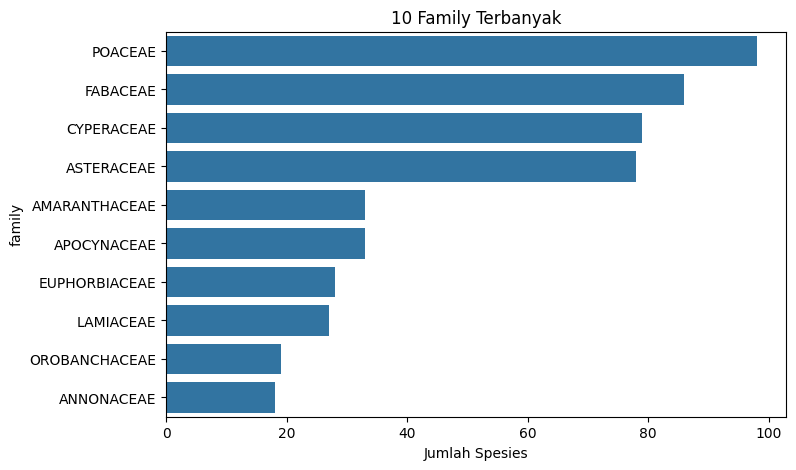

In [21]:
# 4.3 Kategorikal - 10 family terbanyak
top_family = df["family"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_family.values, y=top_family.index)
plt.title("10 Family Terbanyak")
plt.xlabel("Jumlah Spesies")
plt.show()

POACEAE jauh mendominasi dengan hampir 140 spesies dibanding
family lain, wajar karena POACEAE emang family rumput-rumputan yang
besar dan tersebar luas.

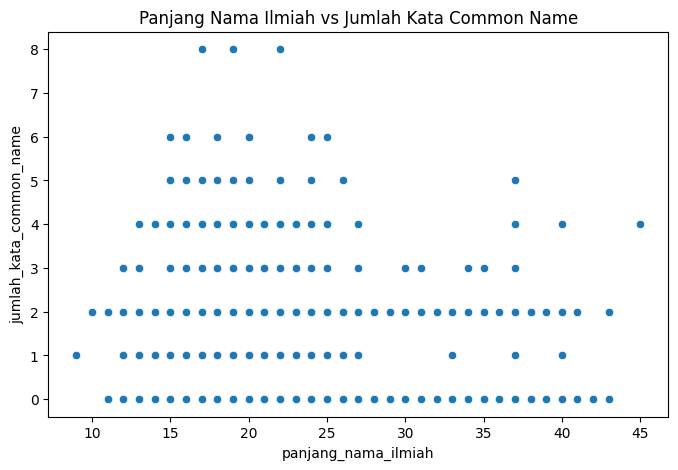

In [22]:
# 4.4 Bivariat - scatter plot 2 atribut numerik
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="panjang_nama_ilmiah", y="jumlah_kata_common_name")
plt.title("Panjang Nama Ilmiah vs Jumlah Kata Common Name")
plt.show()

Titik-titik nyebar acak tanpa pola jelas antara panjang nama
ilmiah dan jumlah kata common name, artinya dua atribut ini sepertinya tidak berhubungan.

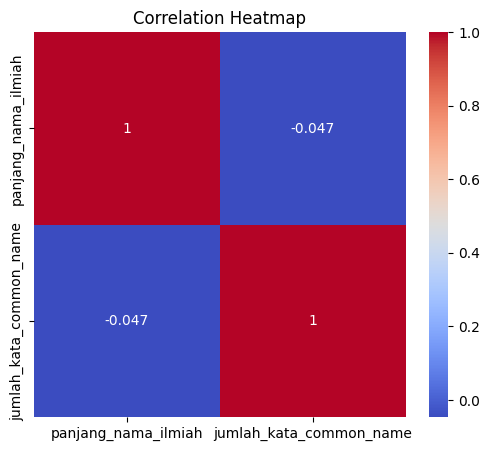

In [23]:
# 4.5 Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df[["panjang_nama_ilmiah", "jumlah_kata_common_name"]].corr(),
             annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Nilai korelasi -0,012 (mendekati 0) mengonfirmasi hasil
scatter plot sebelumnya nggak ada hubungan linear antara dua
atribut numerik ini.

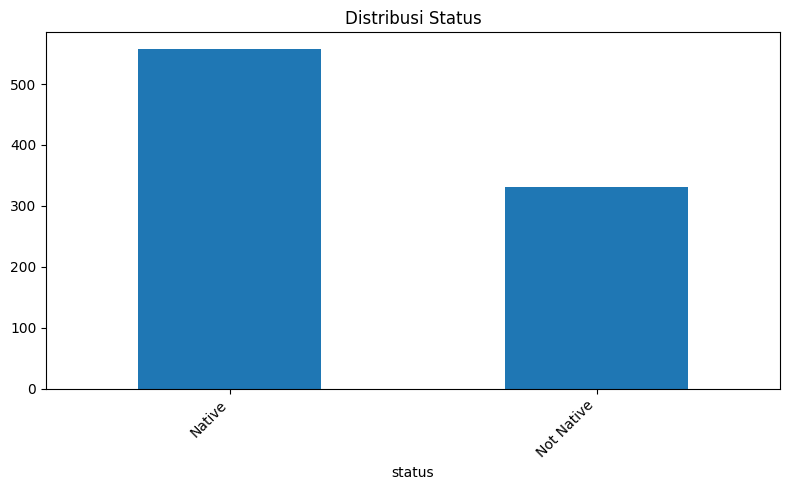

In [24]:
# 4.6 Distribusi status (kategorikal)
plt.figure(figsize=(8,5))
df["status"].value_counts().head(10).plot(kind="bar")
plt.title("Distribusi Status")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Status tertentu jauh lebih dominan dibanding status lain,
menunjukkan sebagian besar spesies di database ini punya
klasifikasi status yang sama.

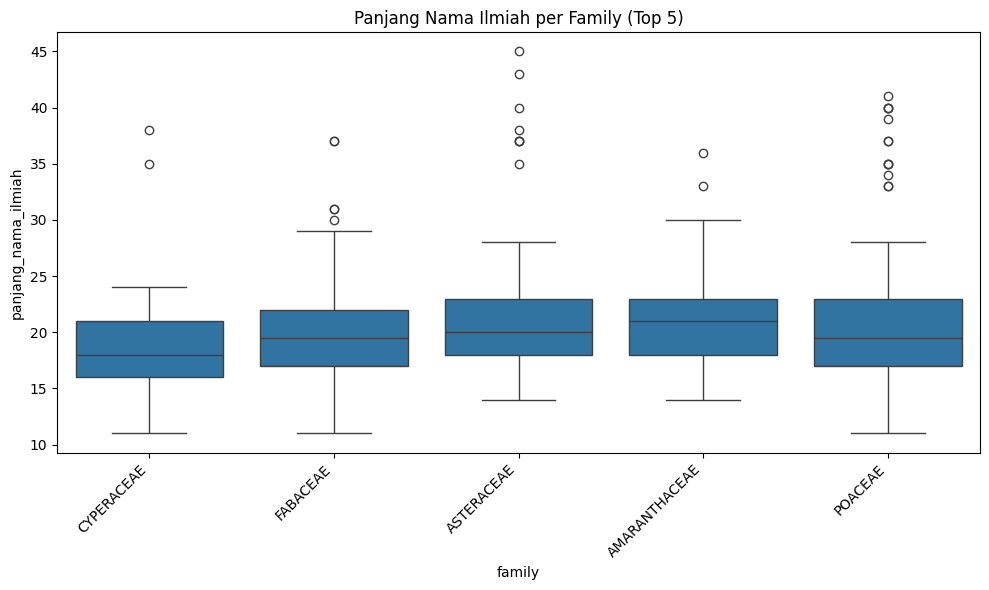

In [25]:
# 4.7 Boxplot per kategori (top 5 family)
top5_family = df["family"].value_counts().head(5).index
data_top5 = df[df["family"].isin(top5_family)]

plt.figure(figsize=(10,6))
sns.boxplot(data=data_top5, x="family", y="panjang_nama_ilmiah")
plt.xticks(rotation=45, ha="right")
plt.title("Panjang Nama Ilmiah per Family (Top 5)")
plt.tight_layout()
plt.show()

LEJEUNEACEAE punya median panjang nama ilmiah paling tinggi
(±24), CYPERACEAE paling rendah (±18). CYPERACEAE dan POACEAE juga
ada beberapa outlier di atas boxnya.

### 5. Laporan Analisis


##### Deskripsi Dataset
Dataset ini didapat dari scraping situs Florida Plant Atlas
(florida.plantatlas.usf.edu) pakai requests dan BeautifulSoup. Total
ada 1642 baris data spesies tumbuhan, dengan 9 kolom: scientific_name,
family, genus, common_name, growth_habit, status, url, dan dua kolom
tambahan yang aku buat sendiri yaitu panjang_nama_ilmiah sama
jumlah_kata_common_name. Kolom-kolom kayak scientific_name, family,
genus, common_name, dan url sifatnya nominal karena cuma nama/kategori
tanpa urutan. Status (Native/Not Native) aku kategoriin ordinal karena
ada makna tingkatan status konservasinya. Dua kolom tambahan yang aku
bikin itu numerik diskrit, soalnya data mentah dari situs sumbernya
sendiri emang nggak ada atribut angka sama sekali.

##### Statistik Deskriptif
Rata-rata panjang nama ilmiah 19,98 karakter, dengan median dan
modus yang deket-deket aja di angka 19, jadi datanya lumayan
simetris di bagian tengah. Standar deviasinya 5,29, rentangnya dari
9 sampe 45 karakter. Buat jumlah kata di common name, rata-ratanya
cuma 1,18 kata, tapi modusnya 0 karena banyak banget common_name
yang kosong. Dari sisi kategorikal, family paling banyak itu POACEAE
dengan 140 spesies, disusul CYPERACEAE dan ASTERACEAE yang masing-
masing 84 spesies, dari total 124 family yang beda-beda. Genus
paling banyak muncul itu Cyperus (59 spesies). Buat status, Native
lebih dominan (545 spesies) dibanding Not Native (344 spesies).

##### Penanganan Data
Ada nilai ** di beberapa kolom yang aku ganti jadi missing value,
soalnya itu placeholder doang dari situs sumbernya, bukan data
beneran. Kolom growth_habit akhirnya aku drop total karena isinya
hampir semua **, jadi nggak kepake buat analisis. Sisanya, kolom
family, genus, common_name, dan status masih ada missing value
sekitar 752-857 dari 1642 baris (kurang lebih 46-52%). Ini kejadian
karena struktur halaman detail tiap spesies di situsnya nggak
seragam, jadi pas scraping ada beberapa halaman yang gagal ketemu
label yang dicari. Missing value ini nggak aku hapus barisnya,
soalnya scientific_name-nya sendiri tetep lengkap dan masih bisa
dipake buat analisis atribut lain. Buat outlier, aku pake metode IQR
dan ketemu 104 outlier di panjang_nama_ilmiah sama 11 outlier di
jumlah_kata_common_name nggak aku buang, cuma dicatet aja karena
emang wajar ada beberapa nama ilmiah yang jauh lebih panjang dari
biasanya.

#### Visualisasi & Interpretasi
Dari histogram panjang nama ilmiah, kelihatan kebanyakan nama ilmiah
itu panjangnya 18-22 karakter, terus abis itu jumlahnya turun cukup
drastis buat yang lebih panjang dari itu, jadi datanya agak skew ke
kanan. Histogram jumlah kata common name nunjukkin mayoritas malah
0 kata, ini karena banyak yang common_name-nya kosong dari awal.

Bar chart 10 family terbanyak nunjukkin POACEAE jauh di atas yang
lain dengan hampir 140 spesies, wajar sih karena POACEAE emang
family rumput-rumputan yang emang gede dan nyebar di mana-mana.

Scatter plot antara panjang nama ilmiah sama jumlah kata common name
nyebar acak tanpa pola yang jelas, dan ini diperkuat sama correlation
heatmap yang nilainya cuma -0,012 (nyaris 0). Jadi kesimpulannya dua
atribut ini nggak ada hubungannya sama sekali.

Bar chart status nunjukkin spesies Native lebih banyak (545) dibanding
Not Native (344), artinya mayoritas tanaman yang kedata di sini
emang tanaman asli Florida.

Terakhir, boxplot panjang nama ilmiah per family (top 5) nunjukkin
LEJEUNEACEAE punya median paling tinggi (sekitar 24), sedangkan
CYPERACEAE paling rendah (sekitar 18). CYPERACEAE dan POACEAE juga
kelihatan ada beberapa outlier di atas boxnya, jadi walau mediannya
biasa aja, tetep ada beberapa spesies yang namanya jauh lebih
panjang dari family-nya sendiri.